In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from environment.bond import Bond
from environment.scenario import MarkovYieldCurveGenerator, DepositBetaLiabilityGenerator
from environment.config import bond_configs, markov_config, T, GAMMA
from models.utils import get_nelson_siegel_yield_batched
from models.source.bdh import (
    DeepALMPolicyDH, OCEUtilityExp, batched_differentiable_rollout,
    eval_step, plot_true_oce_q_function, evaluate_naive_baseline, 
    analyze_trained_allocations_clean, evaluate_deep_alm_dh
)

In [ ]:
K = len(bond_configs)
BOND_MATURITIES = [cfg["maturity_months"] for cfg in bond_configs]
MAX_MATURITY = int(max(BOND_MATURITIES))
BOND_COUPON_DATES = [Bond(**cfg).coupon_dates for cfg in bond_configs]
ACTION_DIM = K + 1

NUM_SCENARIOS = 15_000 
batch_size = 1024   

print(f"Generating {NUM_SCENARIOS} real scenarios...")

safe_config = {k: markov_config[k] for k in ["i0_init", "i1_init", "BETA0_GRID", "BETA1_GRID", "BETA2", "P0", "P1"] if k in markov_config}

y_list, l_list = [], []
for i in range(NUM_SCENARIOS):
    y_path = MarkovYieldCurveGenerator.generate(T * 2, seed=i, pure_grid=True, **safe_config)
    l_path = DepositBetaLiabilityGenerator.generate(y_path, noise_std=0.0, seed=i)
    l_path[T + 1:] = 0.0
    y_list.append(y_path)
    l_list.append(l_path)

yields_tensor = torch.tensor(np.stack(y_list), dtype=torch.float32)
liabilities_tensor = torch.tensor(np.stack(l_list), dtype=torch.float32)

y_dim = yields_tensor.shape[-1]
l_dim = liabilities_tensor.shape[-1]
STATE_DIM  = 1 + MAX_MATURITY + y_dim + l_dim

print(f"Real State Dimension: {STATE_DIM}")

train_size = int(0.8 * NUM_SCENARIOS)
train_dataset = TensorDataset(yields_tensor[:train_size], liabilities_tensor[:train_size])
val_dataset = TensorDataset(yields_tensor[train_size:], liabilities_tensor[train_size:])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Generating 15000 real scenarios...
Real State Dimension: 29


In [3]:
model = DeepALMPolicyDH(state_dim=STATE_DIM, action_dim=ACTION_DIM, T=T)
loss_fn = OCEUtilityExp(gamma=GAMMA)

optimizer = optim.Adam(
    list(model.parameters()) + list(loss_fn.parameters()), 
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print("Model and Optimizer ready.")

Model and Optimizer ready.


In [4]:
epochs = 150
train_losses, val_risks, val_epochs = [], [], []

print("Starting Training...")

for epoch in range(epochs):
    epoch_losses = []
    model.train()
    
    for batch_yields, batch_liabilities in train_loader:
        
        batch_size_current = batch_yields.shape[0]
        random_b1 = 0
        betas_0 = batch_yields[:, 0]
        iy_2m = get_nelson_siegel_yield_batched(2.0 / 12.0, betas_0).squeeze(-1)
        effective_face = random_b1 / (1.0 + iy_2m * (2.0 / 12.0))
        
        init_h = torch.zeros(batch_size_current, len(BOND_MATURITIES), int(max(BOND_MATURITIES)))
        init_c = torch.zeros_like(init_h)
        init_h[:, 0, 1] = effective_face / 100.0
        init_c[:, 0, 1] = iy_2m
        # -----------------------------------------------------------
        
        optimizer.zero_grad()
        
        terminal_value, _, _, _ = batched_differentiable_rollout(
            model=model, yields_batch=batch_yields, liabilities_batch=batch_liabilities, 
            T=T, bond_maturities=BOND_MATURITIES, bond_coupon_dates=BOND_COUPON_DATES,
            initial_holdings=init_h, initial_coupons=init_c, initial_cash=markov_config["W0"]
        )
        
        loss = loss_fn(terminal_value)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_losses.append(loss.item())
        
    scheduler.step()
    
    avg_train_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_train_loss)
    
    # --- VALIDATION PHASE ---
    if (epoch + 1) % 5 == 0:
        epoch_val_risks = []
        for batch_yields_val, batch_liab_val in val_loader:
            val_risk = eval_step(
                model, GAMMA, batch_yields_val, batch_liab_val,
                T, BOND_MATURITIES, BOND_COUPON_DATES
            )
            epoch_val_risks.append(val_risk)
            
        avg_val_risk = sum(epoch_val_risks) / len(epoch_val_risks)
        val_risks.append(avg_val_risk)
        val_epochs.append(epoch + 1)
        
        print(f"Epoch {epoch+1:04d}/{epochs} | Train OCE Loss: {avg_train_loss:.4f} | Val Risk (Entropic): ${avg_val_risk:.2f}")

# Save the model
if T == 1:
    model.save("saved_models/deep_hedging_model_T1.pth")
else:
    model.save("saved_models/deep_hedging_model.pth")

Starting Training...
Epoch 0005/150 | Train OCE Loss: 111.2112 | Val Risk (Entropic): $86.12
Epoch 0010/150 | Train OCE Loss: 35.7361 | Val Risk (Entropic): $34.70
Epoch 0015/150 | Train OCE Loss: 34.6107 | Val Risk (Entropic): $33.82
Epoch 0020/150 | Train OCE Loss: 34.5006 | Val Risk (Entropic): $33.78
Epoch 0025/150 | Train OCE Loss: 34.5071 | Val Risk (Entropic): $33.78
Epoch 0030/150 | Train OCE Loss: 34.5364 | Val Risk (Entropic): $33.77
Epoch 0035/150 | Train OCE Loss: 34.4613 | Val Risk (Entropic): $33.77
Epoch 0040/150 | Train OCE Loss: 34.6020 | Val Risk (Entropic): $33.77
Epoch 0045/150 | Train OCE Loss: 34.2558 | Val Risk (Entropic): $33.77
Epoch 0050/150 | Train OCE Loss: 34.4154 | Val Risk (Entropic): $33.77
Epoch 0055/150 | Train OCE Loss: 34.4658 | Val Risk (Entropic): $33.77
Epoch 0060/150 | Train OCE Loss: 34.3693 | Val Risk (Entropic): $33.77
Epoch 0065/150 | Train OCE Loss: 34.4687 | Val Risk (Entropic): $33.77
Epoch 0070/150 | Train OCE Loss: 34.3651 | Val Risk (En

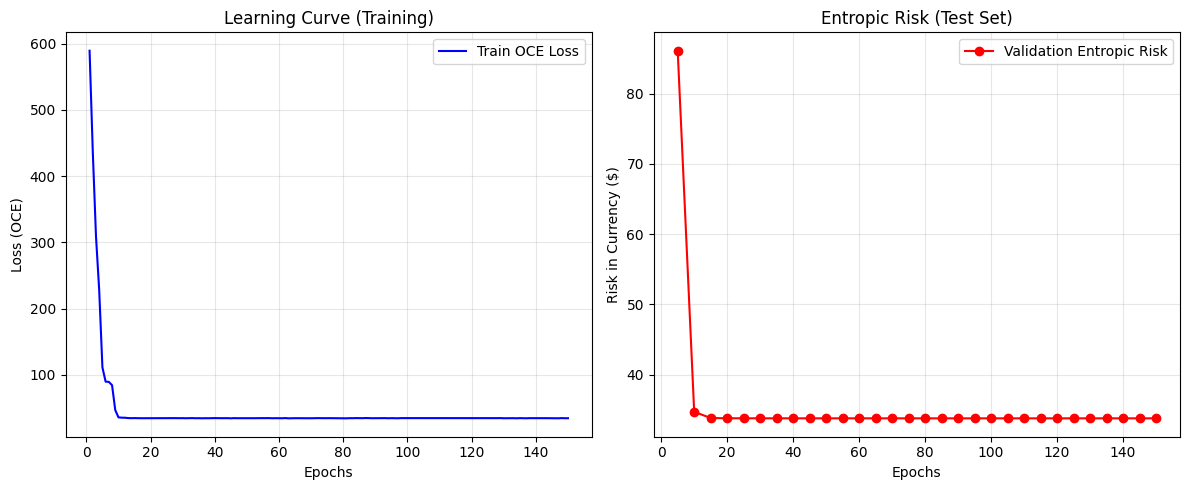

In [5]:
# Plot Training Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train OCE Loss', color='blue')
plt.title("Learning Curve (Training)")
plt.xlabel("Epochs")
plt.ylabel("Loss (OCE)")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_epochs, val_risks, label='Validation Entropic Risk', color='red', marker='o')
plt.title("Entropic Risk (Test Set)")
plt.xlabel("Epochs")
plt.ylabel("Risk in Currency ($)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Engine Analysis 
analyze_trained_allocations_clean(
    model=model, dataloader=val_loader, T=T, 
    bond_maturities=BOND_MATURITIES, bond_coupon_dates=BOND_COUPON_DATES, scenario_idx=0,
    initial_cash=markov_config["W0"]
)

 ACCURATE SIMULATION ENGINE ANALYSIS (SCENARIO 0)
  [Month t=00] | Balance Cash: $ 1940.71 | Expected Liability: $   59.29
               | Investable Budget: $ 1940.71
               | Network Choice (%) : [   0.0%,    0.0%,    0.0%,    0.0%,  100.0%,    0.0%] (Bonds -> Cash)
               | Actual Invest. ($) : [$   0.00, $   0.00, $   0.01, $   0.01, $1940.69, $   0.00]
               -------------------------------------------------------------------------
  [Month t=01] | Balance Cash: $ -753.25 | Expected Liability: $   52.51
               | [BANKRUPTCY] Budget frozen at $0.00! No purchases allowed.
               | Network Choice (%) : [   2.0%,    2.9%,   26.0%,   25.2%,   42.0%,    1.9%] (Bonds -> Cash)
               | Actual Invest. ($) : [$   0.00, $   0.00, $   0.00, $   0.00, $   0.00, $   0.00]
               -------------------------------------------------------------------------
  [Month t=02] | Balance Cash: $ -795.76 | Expected Liability: $   42.51
               

In [7]:
# Full Out-Of-Sample DeepALM Evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metrics, history_log, terminal_values = evaluate_deep_alm_dh(
    model=model, markov_config=markov_config, eval_episodes=2000, 
    device=device, seed_offset=1000000, log_scenario_idx=0, gamma=GAMMA
)


=== DeepALM DH Evaluation Results ===
Mean NAV:       -29.87 ± 108.86
Median NAV:     -26.08
VaR (95%):      -213.30 (Worst 5% cutoff)
CVaR (95%):     -258.21 (Average of worst 5%)
Min / Max NAV:  -363.31 / 297.49
Entropic Risk:  35.8093
Default Rate:   100.00%
Total Defaults: 2000 out of 2000 episodes


In [8]:
# Full Out-Of-Sample DeepALM Evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metrics, history_log, terminal_values = evaluate_deep_alm_dh(
    model=model, markov_config=markov_config, eval_episodes=100_000,
    device=device, seed_offset=1_000_000, log_scenario_idx=0, gamma=GAMMA
)


=== DeepALM DH Evaluation Results ===
Mean NAV:       -28.42 ± 108.43
Median NAV:     -28.42
VaR (95%):      -207.09 (Worst 5% cutoff)
CVaR (95%):     -250.06 (Average of worst 5%)
Min / Max NAV:  -463.79 / 415.53
Entropic Risk:  34.3005
Default Rate:   100.00%
Total Defaults: 100000 out of 100000 episodes
